In [2]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file("key.json") # lokalizacja pobranego klucza z punktu 1.4.

client = bigquery.Client(credentials=credentials, project=credentials.project_id)

In [3]:
query = """

select r20_21.*, stations.*

from (

select *
from `bigquery-public-data.noaa_gsod.gsod2020`

union all

select *
from `bigquery-public-data.noaa_gsod.gsod2021`

) as r20_21
join `bigquery-public-data.noaa_gsod.stations` as stations on r20_21.stn = stations.usaf and r20_21.wban = stations.wban
"""

query_job = client.query(query)
query_result = query_job.result()
# weather and stations
dfwas = query_result.to_dataframe()

Część 1

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = dfwas.copy()
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["month"] = data["date"].dt.month
data["mxpsd"] = pd.to_numeric(data["mxpsd"], errors="coerce")

missing_codes = {
    "temp": 9999.9,
    "max": 9999.9,
    "min": 9999.9,
    "dewp": 9999.9,
    "slp": 9999.9,
    "stp": 9999.9,
    "visib": 999.9,
    "wdsp": 999.9,
    "mxpsd": 999.9,
    "gust": 999.9,
    "prcp": 99.99
}

for col, code in missing_codes.items():
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")
        data[col] = data[col].replace(code, np.nan)

sns.set(style="whitegrid")

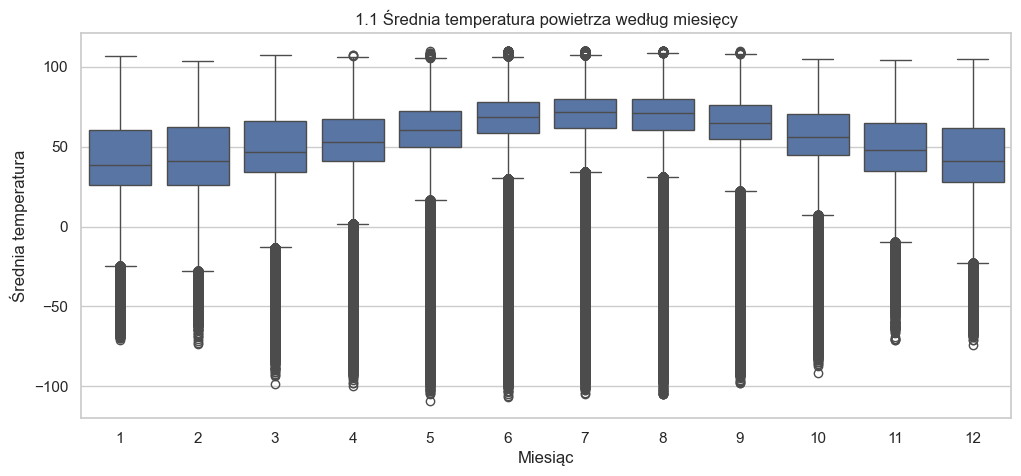

In [5]:
#1.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="temp", data=data)
plt.title("1.1 Średnia temperatura powietrza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia temperatura")
plt.show()

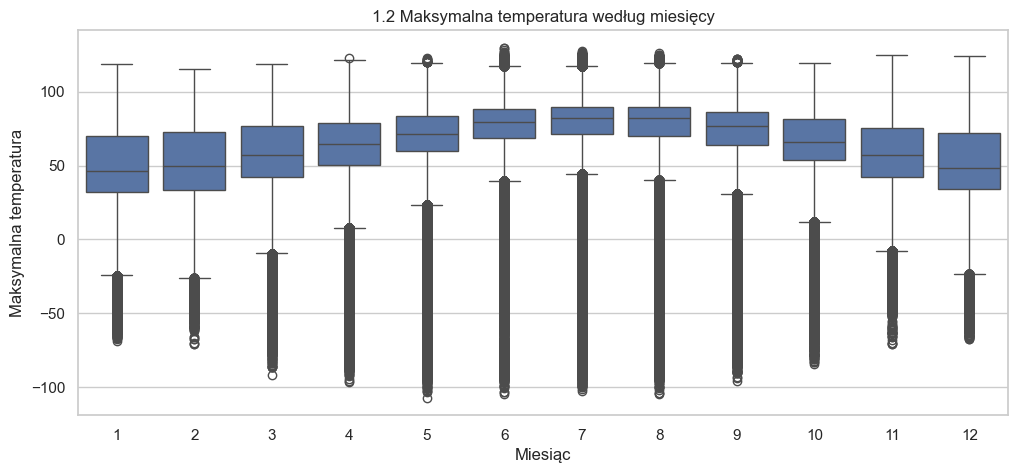

In [6]:
#1.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="max", data=data)
plt.title("1.2 Maksymalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Maksymalna temperatura")
plt.show()

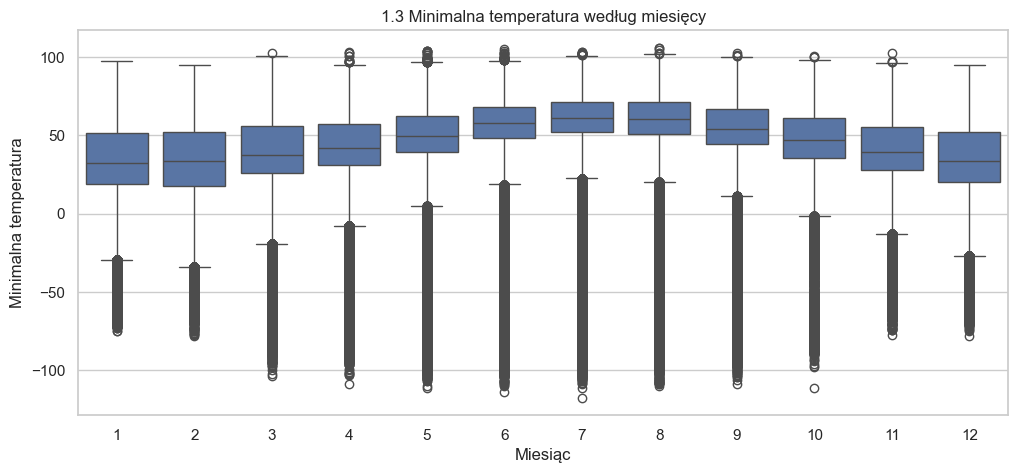

In [7]:
#1.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="min", data=data)
plt.title("1.3 Minimalna temperatura według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Minimalna temperatura")
plt.show()

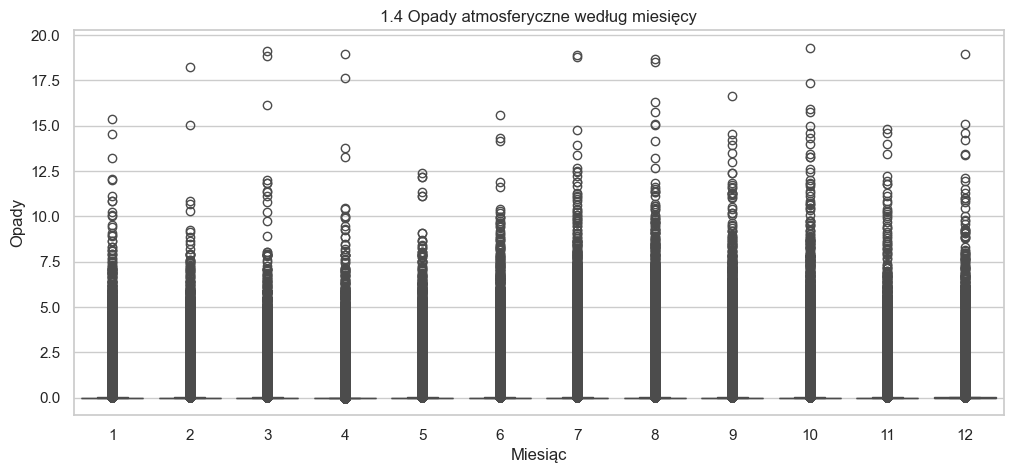

In [8]:
#1.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="prcp", data=data)
plt.title("1.4 Opady atmosferyczne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Opady")
plt.show()

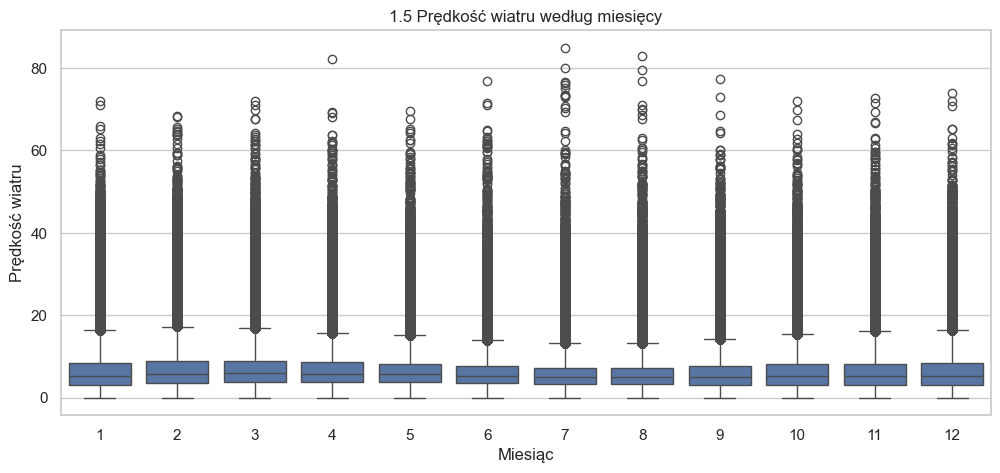

In [9]:
#1.5
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="wdsp", data=data)
plt.title("1.5 Prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Prędkość wiatru")
plt.show()

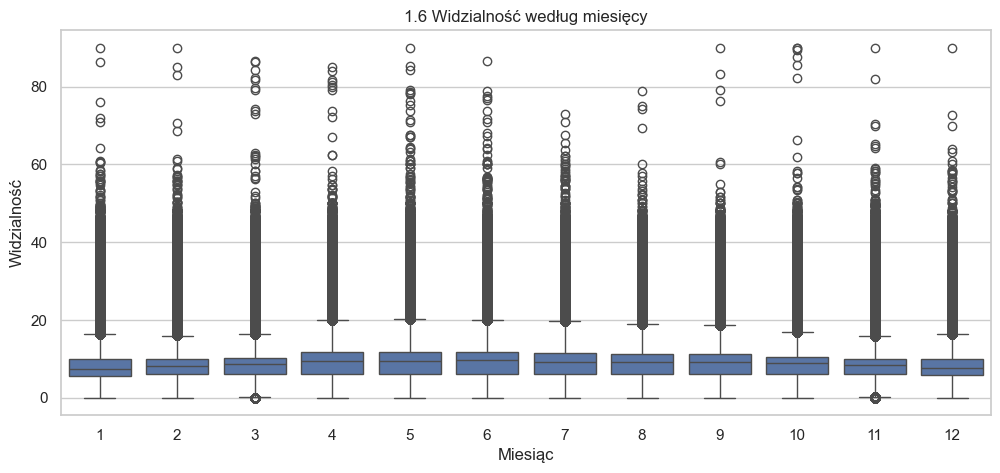

In [10]:
#1.6
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="visib", data=data)
plt.title("1.6 Widzialność według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Widzialność")
plt.show()

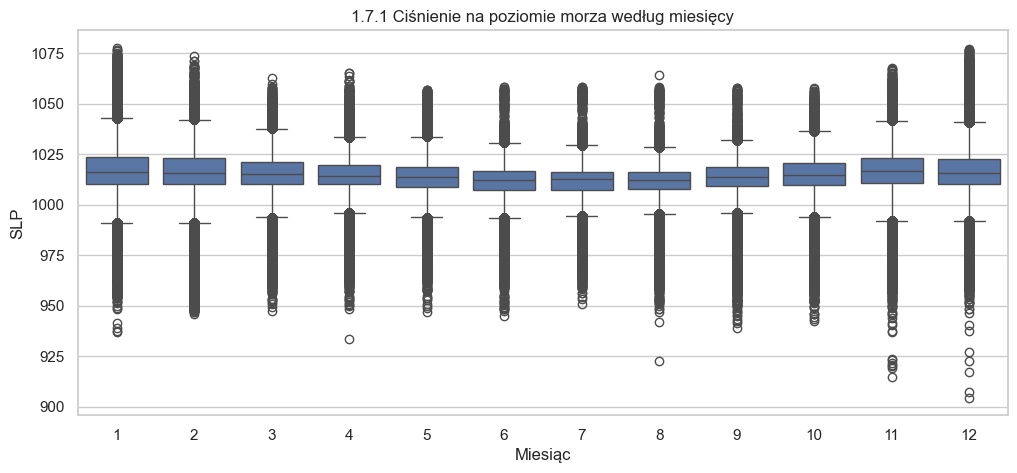

In [11]:
#1.7.1
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="slp", data=data)
plt.title("1.7.1 Ciśnienie na poziomie morza według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("SLP")
plt.show()

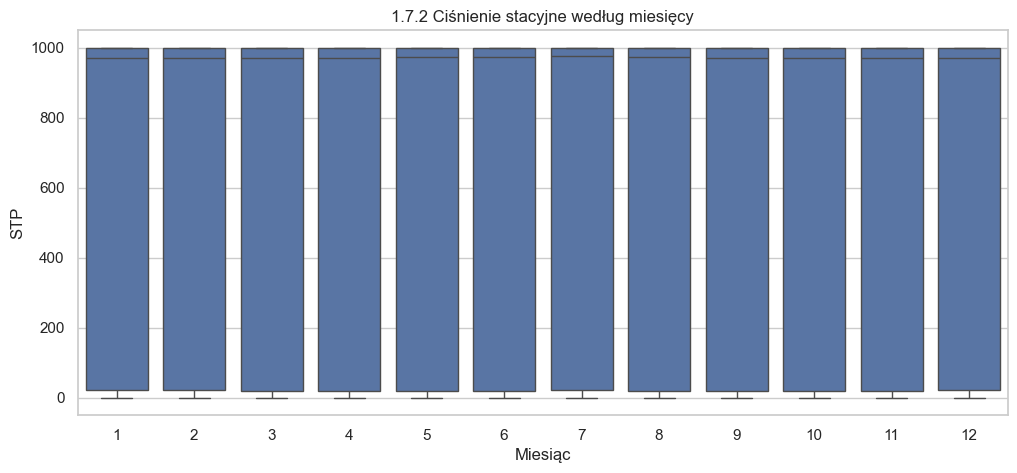

In [12]:
#1.7.2
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="stp", data=data)
plt.title("1.7.2 Ciśnienie stacyjne według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("STP")
plt.show()

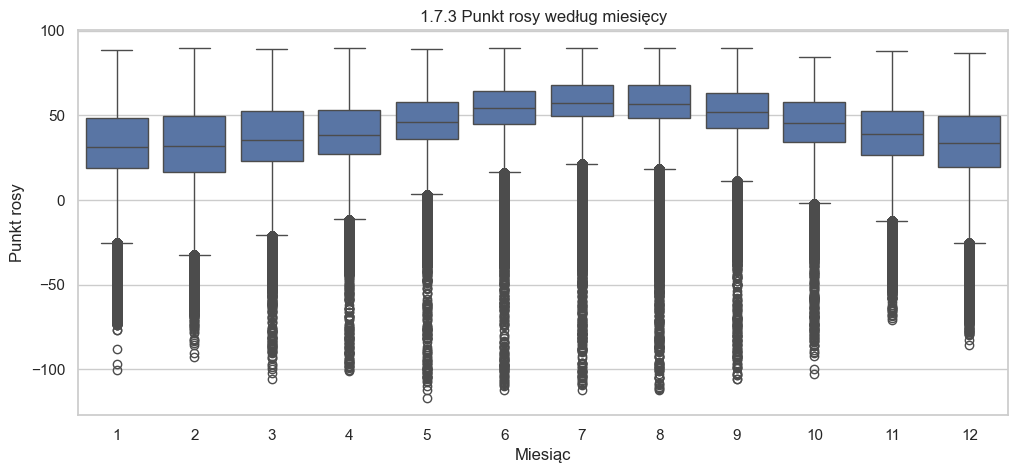

In [13]:
#1.7.3
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="dewp", data=data)
plt.title("1.7.3 Punkt rosy według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("Punkt rosy")
plt.show()

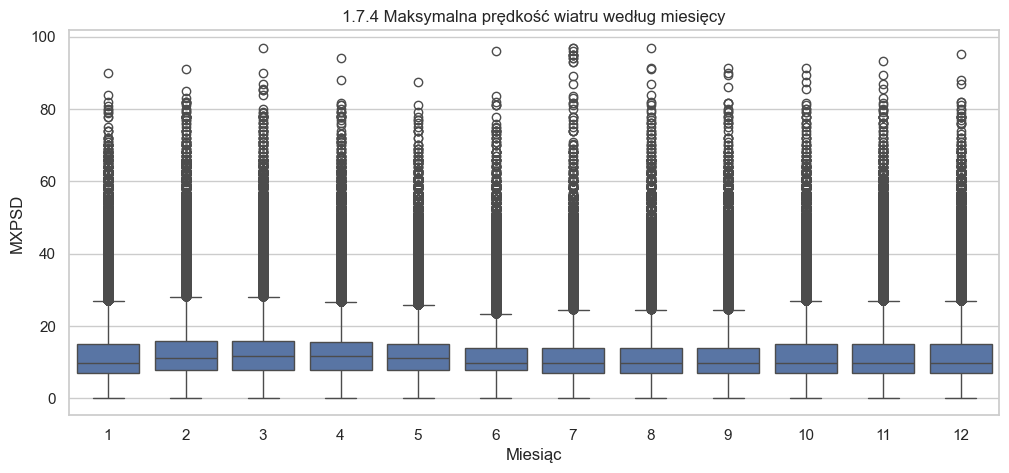

In [14]:
#1.7.4
plt.figure(figsize=(12, 5))
sns.boxplot(x="month", y="mxpsd", data=data)
plt.title("1.7.4 Maksymalna prędkość wiatru według miesięcy")
plt.xlabel("Miesiąc")
plt.ylabel("MXPSD")
plt.show()

Część 2

In [15]:
#średnia temperatura oraz prędkość wiatru

if 'month' not in data.columns:
    data["month"] = data["date"].dt.month

zmienne_do_analizy = ["temp", "wdsp"]

for col in zmienne_do_analizy:
    print(col)
    for month in sorted(data["month"].unique()):
        monthly_data = data[data["month"] == month][col].dropna()

        Q1 = monthly_data.quantile(0.25)
        Q3 = monthly_data.quantile(0.75)
        IQR = Q3 - Q1

        min_normal = Q1 - 1.5 * IQR
        max_normal = Q3 + 1.5 * IQR

        outliers_lower = []
        outliers_upper = []
        for md in monthly_data:
            if md < min_normal:
                outliers_lower.append(md)
            elif md > max_normal:
                outliers_upper.append(md)

    print(f"Miesiąc {month}: Znaleziono {len(outliers_lower) + len(outliers_upper)} outlierów (Zakres: {min_normal:.4f} do {max_normal:.4f})")

    if len(outliers_lower):
        print(f"Min: {min(outliers_lower)}")

    if len(outliers_upper):
        print(f"Max: {max(outliers_upper)}")

# po prześledzeniu wyników wydaje się, że outliery to wartości skrajne wynikające z rzeczywistych zjawisk pogodowych.
# na podstawie przeprowadzonej analizy postanowiłem pozostawić je w zbiorze danych.

temp
Miesiąc 12: Znaleziono 11047 outlierów (Zakres: -23.1000 do 112.1000)
Min: -74.0
wdsp
Miesiąc 12: Znaleziono 27687 outlierów (Zakres: -4.7500 do 16.4500)
Max: 74.0


Część 3

In [16]:
data = dfwas.copy()

data["date"] = pd.to_datetime(data["date"], errors="coerce")

print(data.dtypes)

stn                             object
wban                            object
date                    datetime64[ns]
year                            object
mo                              object
da                              object
temp                           float64
count_temp                       Int64
dewp                           float64
count_dewp                       Int64
slp                            float64
count_slp                        Int64
stp                            float64
count_stp                        Int64
visib                          float64
count_visib                      Int64
wdsp                            object
count_wdsp                      object
mxpsd                           object
gust                           float64
max                            float64
flag_max                        object
min                            float64
flag_min                        object
prcp                           float64
flag_prcp                

In [17]:
#3.2
weather_cols = ["temp", "max", "min", "prcp", "wdsp", "visib", "slp", "stp", "dewp", "mxpsd"]

for col in weather_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

if "temp" in data.columns:
    data["temp"] = data["temp"].replace(9999.9, np.nan)
if "max" in data.columns:
    data["max"] = data["max"].replace(9999.9, np.nan)
if "min" in data.columns:
    data["min"] = data["min"].replace(9999.9, np.nan)
if "dewp" in data.columns:
    data["dewp"] = data["dewp"].replace(9999.9, np.nan)
if "slp" in data.columns:
    data["slp"] = data["slp"].replace(9999.9, np.nan)
if "stp" in data.columns:
    data["stp"] = data["stp"].replace(9999.9, np.nan)

if "visib" in data.columns:
    data["visib"] = data["visib"].replace(999.9, np.nan)
if "wdsp" in data.columns:
    data["wdsp"] = data["wdsp"].replace(999.9, np.nan)
if "mxpsd" in data.columns:
    data["mxpsd"] = data["mxpsd"].replace(999.9, np.nan)

if "prcp" in data.columns:
    data["prcp"] = data["prcp"].replace(99.99, np.nan)

In [18]:
#3.1
missing_summary = pd.DataFrame({
    "liczba_brakow": data.isna().sum(),
    "procent_brakow": round(data.isna().sum() / len(data) * 100, 2)
})

missing_summary = missing_summary.sort_values("liczba_brakow", ascending=False)
missing_summary

,liczba_brakow,procent_brakow
state,6207545,76.45
flag_min,4913008,60.51
flag_max,4786959,58.96
call,3926108,48.35
slp,2794527,34.42
visib,2169612,26.72
flag_prcp,604290,7.44
prcp,604290,7.44
mxpsd,462639,5.70
dewp,395050,4.87


In [19]:
#3.3
data = data.sort_values("date").copy()

selected_cols = ["wdsp", "prcp"]

data_mean = data.copy()
data_median = data.copy()
data_interp = data.copy()

# imputacja średnią
for col in selected_cols:
    data_mean[col] = data_mean[col].fillna(data_mean[col].mean())

# imputacja medianą
for col in selected_cols:
    data_median[col] = data_median[col].fillna(data_median[col].median())

#interpolacja w czasie
data_interp = data_interp.set_index("date")

for col in selected_cols:
    data_interp[col] = data_interp[col].interpolate(method="time")

data_interp = data_interp.reset_index()

In [20]:
#3.4
for col in selected_cols:
    print(f"\n===== {col.upper()} =====")

    print("\nOryginalne dane:")
    print(data[col].describe())

    print("\nPo imputacji średnią:")
    print(data_mean[col].describe())

    print("\nPo imputacji medianą:")
    print(data_median[col].describe())

    print("\nPo interpolacji w czasie:")
    print(data_interp[col].describe())


===== WDSP =====

Oryginalne dane:
count    7.797877e+06
mean     6.340804e+00
std      4.434327e+00
min      0.000000e+00
25%      3.400000e+00
50%      5.300000e+00
75%      8.200000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po imputacji średnią:
count    8.119543e+06
mean     6.340804e+00
std      4.345604e+00
min      0.000000e+00
25%      3.500000e+00
50%      5.500000e+00
75%      8.000000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po imputacji medianą:
count    8.119543e+06
mean     6.299571e+00
std      4.350343e+00
min      0.000000e+00
25%      3.500000e+00
50%      5.300000e+00
75%      8.000000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

Po interpolacji w czasie:
count    8.119543e+06
mean     6.354847e+00
std      4.453393e+00
min      0.000000e+00
25%      3.400000e+00
50%      5.400000e+00
75%      8.200000e+00
max      8.490000e+01
Name: wdsp, dtype: float64

===== PRCP =====

Oryginalne dane:
count    7.515253e+06
mean     7.583993e-02

Część 4

In [22]:
# Obliczenia statystyczne (m.in. średnia, mediana, moda, odchylenie standardowe) pozwalają na zrozumienie rozkładu danych oraz na identyfikację ewentualnych anomalii lub nietypowych wartości.

# 4.1. średnia temperatura, opady i prędkość wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,


# "PL": "Poland",
# "QA": "Qatar",
# "RI": "Serbia",
# "SP": "Spain",
# "SZ": "Switzerland",
# 'IR': 'iran (islamic republic of)',
# "US": "United States of America",
# 'ch': 'china, mainland',
# "CI": "Chile",
# "RS": "Russian Federation",

countries_to_check = ["PL", "QA", "RI", "SP", "SZ", "IR", "US", "CH", "CI", "RS"]
data['month'] = data['date'].dt.month
df_lip = data[(data['month'] == 7) & (data['country'].isin(countries_to_check))]
df_4_1 = df_lip.groupby('country')[['temp', 'prcp', 'wdsp']].mean().reset_index()

print(f"\n4.1. Średnie wartości dla lipca\n {df_4_1}:")

# 4.2. średnia zmiana temperatury i opadów dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,

df_lip = data.sort_values(['stn', 'date'])
df_lip['temp_change'] = df_lip.groupby('stn')['temp'].diff()
df_lip['prcp_change'] = df_lip.groupby('stn')['prcp'].diff()
df_lip = data[(data['month'] == 7) & (data['country'].isin(countries_to_check))]

df_4_2 = df_lip.groupby('country')[['temp_change', 'prcp_change']].mean().reset_index()

print(f"\n4.2. Średnia dzienna zmiana w lipcu :\n{df_4_2}:")


# 4.3. mediana temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów lub stacji w wybranym miesiącu,
df_4_3 = df_lip.groupby('country')[['temp', 'prcp', 'wdsp']].median().reset_index()

print(f"\n4.3. Mediana wartości dla lipca \n{df_4_3}:")

# 4.4. odchylenie standardowe temperatury, opadów i prędkości wiatru,
df_4_4 = df_lip[['temp', 'prcp', 'wdsp']].std()
print(f"\n4.4. Odchylenie standardowe: \n{df_4_4}:")

# 4.5. minimalna, średnia i maksymalna temperatury, opadów i prędkości wiatru dla co najmniej 10 wybranych krajów,
df_4_5 = df_lip.groupby('country').agg({
    'temp': ['min', 'mean', 'max'],
    'prcp': ['min', 'mean', 'max'],
    'wdsp': ['min', 'mean', 'max']
})
print(f"\n4.5. Zestawienie Min/Średnia/Max: \n{df_4_5}:")


# Skorzystaj ze swojego połączonego zbioru danych (pogoda + rolnictwo) i oblicz średnią temperaturę oraz sumę opadów w wybranym roku dla co najmniej 10 krajów, a następnie porównaj te wartości z produkcją lub plonem wybranej rośliny w tych krajach. Spróbuj ocenić, czy można zauważyć zależność pomiędzy warunkami pogodowymi a produkcją rolną.

df_4_6 = pd.read_csv('df_merged.csv')
df_4_6 = df_4_6[df_4_6['country'].isin(countries_to_check) & (df_4_6['year'] == 2021) & (df_4_6['Item'] == 'Rye') &
                (df_4_6['Unit'] == 'kg/ha')]
sf4_6 = df_4_6.groupby('country')[['temp', 'prcp', 'Value']].mean()


# Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje.
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# temp
axes[0].bar(sf4_6.index, sf4_6['temp'], color='orange', alpha=0.8)
axes[0].set_title('Średnia temperatura roczna w 2021 r.', fontsize=14)
axes[0].set_ylabel('Temperatura [°F]', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Opady
axes[1].bar(sf4_6.index, sf4_6['prcp'], color='skyblue', alpha=0.8)
axes[1].set_title('Średnie opady atmosferyczne w 2021 r.', fontsize=14)
axes[1].set_ylabel('Opady [cale]', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

#Żyt0
axes[2].bar(sf4_6.index, sf4_6['Value'], color='forestgreen', alpha=0.8)
axes[2].set_title('Plon żyta w 2021 r.', fontsize=14)
axes[2].set_ylabel('Plon [kg/ha]', fontsize=12)
axes[2].set_xlabel('Kraj', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



4.1. Średnie wartości dla lipca
   country       temp      prcp      wdsp
0      CH  76.014621  0.192550  4.979705
1      CI  47.581171  0.072991  6.249272
2      IR  88.334638  0.010028  7.242303
3      PL  66.538817  0.088442  5.776602
4      QA  97.012212  0.001313  6.933180
5      RI  72.411183  0.102868  4.035865
6      RS  64.071135  0.082099  5.048661
7      SP  75.157067  0.024333  6.551839
8      SZ  60.963903  0.173184  4.748422
9      US  74.542821  0.080344  5.414362:


KeyError: "Columns not found: 'temp_change', 'prcp_change'"

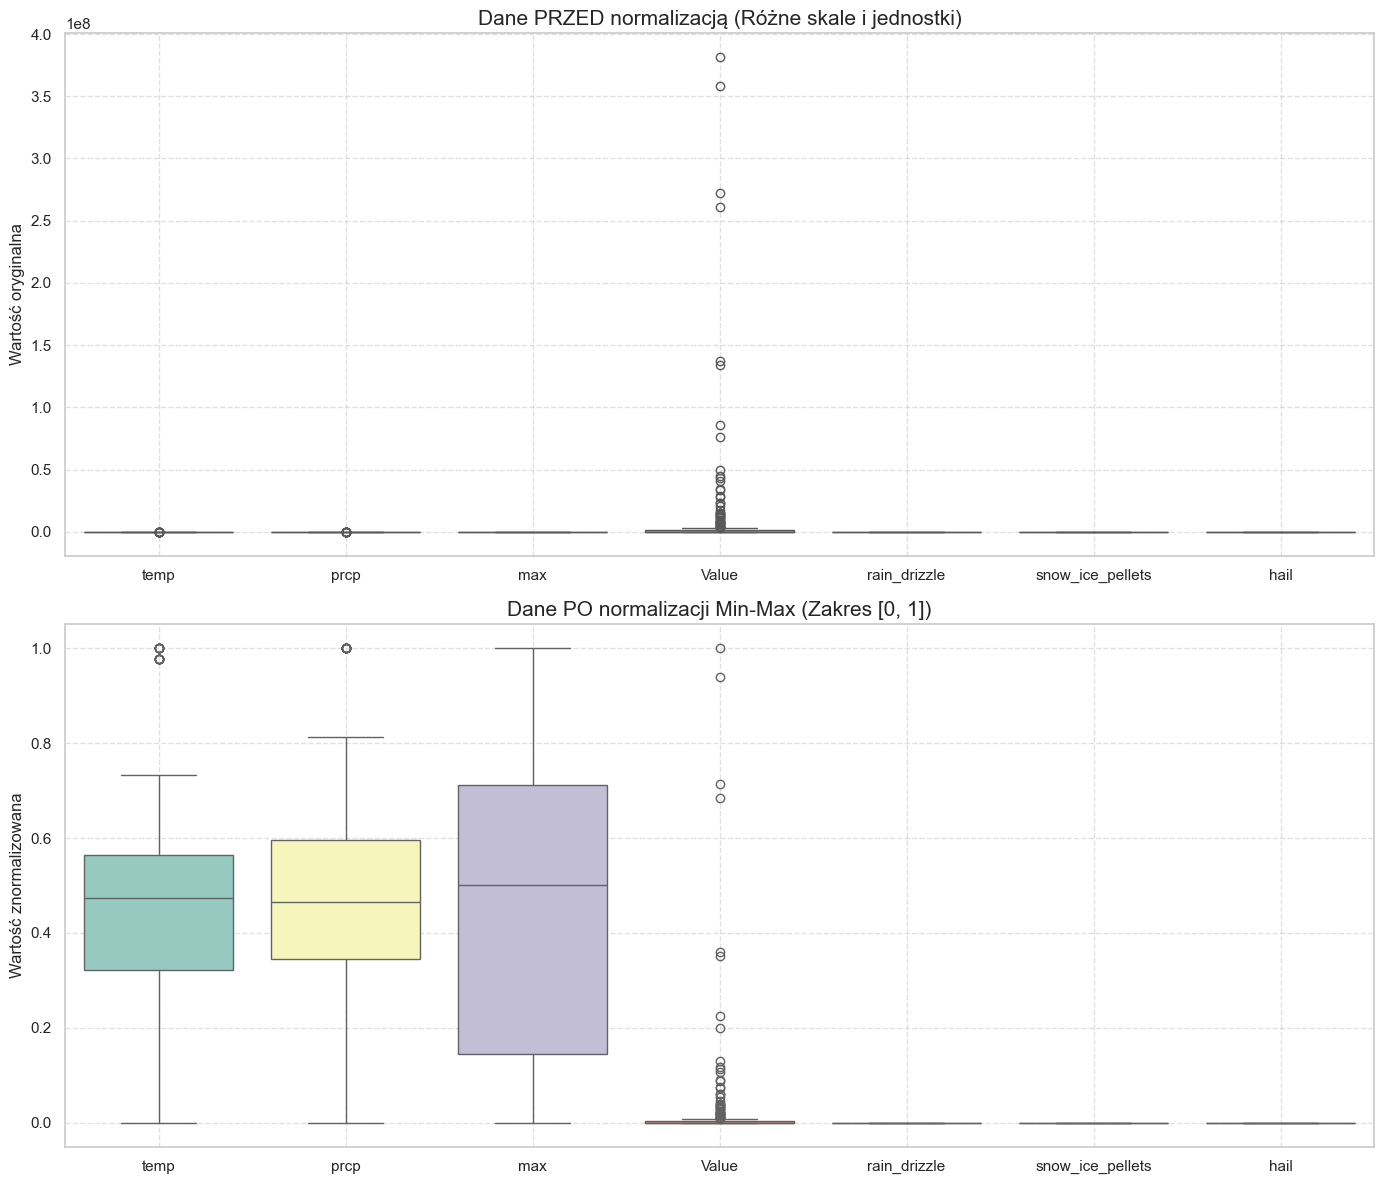

In [23]:
# Normalizacja danych polega na przeskalowaniu wartości zmiennych do określonego zakresu, np. [0, 1], co ułatwia porównanie różnych zmiennych między sobą.
#
# Wykonaj normalizację wybranych zmiennych przy użyciu tej samej metody skalowania (np. normalizacji min-max z zakresu [0,1]):

# 5.1. temperatura,
# 5.2. opady,
# 5.3. prędkość wiatru
# 5.4. wybrana zmienna rolnicza,
# 5.5. co najmniej 3 dodatkowe zmienne, które uznasz za istotne.
df_5 = pd.read_csv('df_merged.csv')
df_5 = df_5[['country', 'temp', 'prcp', 'max', 'Value', 'rain_drizzle', 'snow_ice_pellets', 'hail']]
df_5 = df_5[(df_5['country'].isin(countries_to_check))].reset_index(drop=True)

df_5_normalized = df_5.copy()
for col in df_5_normalized.columns:
    if col != 'country':
        wmax = df_5_normalized[col].max()
        wmin = df_5_normalized[col].min()
        if wmax != wmin:
            for i in range(len(df_5_normalized)):
                df_5_normalized.loc[i, col] = (df_5_normalized.loc[i, col] - wmin) / (wmax - wmin)
        else:
            for i in range(len(df_5_normalized)):
                df_5_normalized.loc[i, col] = 0.0

# Przygotuj wykresy w celu porównania otrzymanych wyników przed i po normalizacji. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi, itp.). Przeanalizuj otrzymane wizualizacje i oceń czy normalizacja ułatwia porównywanie różnych zmiennych.


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(data=df_5.drop(columns='country'), ax=ax1, palette="Set2")
ax1.set_title('Dane PRZED normalizacją (Różne skale i jednostki)', fontsize=15)
ax1.set_ylabel('Wartość oryginalna')
ax1.grid(True, linestyle='--', alpha=0.6)

sns.boxplot(data=df_5_normalized.drop(columns='country'), ax=ax2, palette="Set3")
ax2.set_title('Dane PO normalizacji Min-Max (Zakres [0, 1])', fontsize=15)
ax2.set_ylabel('Wartość znormalizowana')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



Część 6

In [52]:
import seaborn as sns
df_2 = pd.read_csv('df_merged.csv')
df_3 = pd.read_csv('df_weather_co2.csv')
df = pd.read_csv('dfp5.csv')
print(df.dtypes)

/var/folders/g5/89b1s0kn5wg8yytqmw27gggr0000gn/T/ipykernel_1715/1218015048.py:4: DtypeWarning: Columns (0,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dfp5.csv')


stn                      object
wban                      int64
date                     object
da                        int64
mo                        int64
year                      int64
temp                    float64
min                     float64
max                     float64
prcp                    float64
flag_prcp                object
wdsp                    float64
mxpsd                   float64
gust                    float64
name                     object
country                  object
state                    object
lat                     float64
lon                     float64
elev                    float64
fog                        bool
rain_drizzle               bool
snow_ice_pellets           bool
hail                       bool
thunder                    bool
tornado_funnel_cloud       bool
sndp                    float64
dtype: object


In [25]:
print(df.columns.tolist())

['stn', 'wban', 'date', 'da', 'mo', 'year', 'temp', 'min', 'max', 'prcp', 'flag_prcp', 'wdsp', 'mxpsd', 'gust', 'name', 'country', 'state', 'lat', 'lon', 'elev', 'fog', 'rain_drizzle', 'snow_ice_pellets', 'hail', 'thunder', 'tornado_funnel_cloud', 'sndp']


In [26]:
def correlation_heatmap(dataframe, cols, title):
    corr = dataframe[cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.figure(figsize=(8, 6))
    plt.tight_layout()
    plt.show()

    return corr

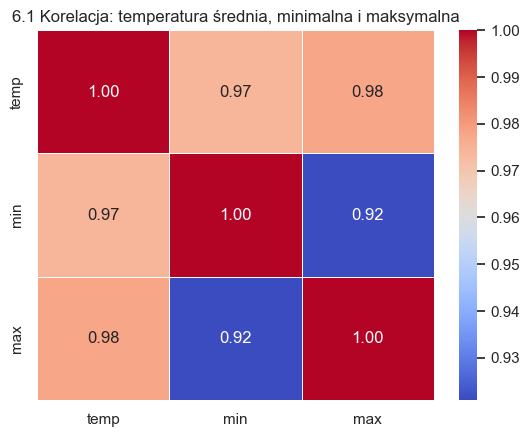

<Figure size 800x600 with 0 Axes>

          temp       min       max
temp  1.000000  0.974326  0.977575
min   0.974326  1.000000  0.920983
max   0.977575  0.920983  1.000000


In [27]:
#6.1
cols_61 = ["temp", "min", "max"]

corr_61 = correlation_heatmap(
    df,
    cols_61,
    "6.1 Korelacja: temperatura średnia, minimalna i maksymalna"
)

print(corr_61)

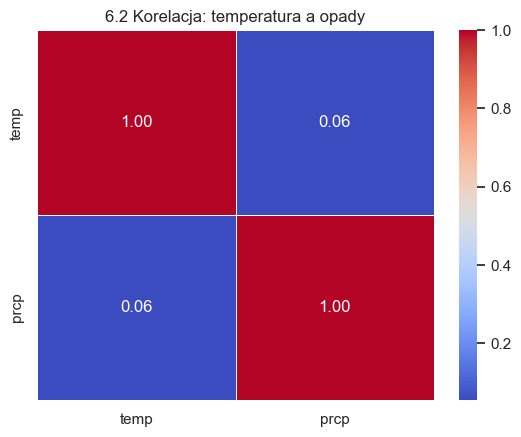

<Figure size 800x600 with 0 Axes>

          temp      prcp
temp  1.000000  0.055738
prcp  0.055738  1.000000


In [28]:
#6.2
cols_62 = ["temp", "prcp"]

corr_62 = correlation_heatmap(
    df,
    cols_62,
    "6.2 Korelacja: temperatura a opady"
)

print(corr_62)

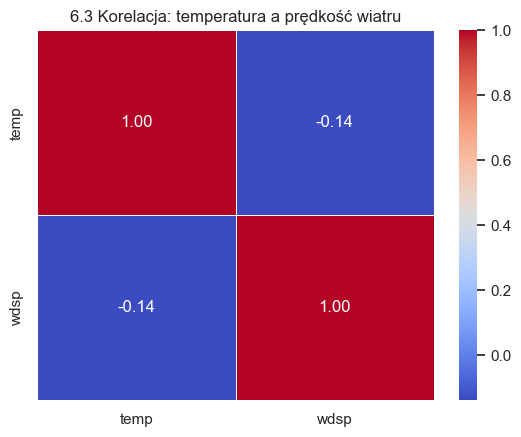

<Figure size 800x600 with 0 Axes>

          temp      wdsp
temp  1.000000 -0.138411
wdsp -0.138411  1.000000


In [29]:
#6.3
cols_63 = ["temp", "wdsp"]

corr_63 = correlation_heatmap(
    df,
    cols_63,
    "6.3 Korelacja: temperatura a prędkość wiatru"
)

print(corr_63)

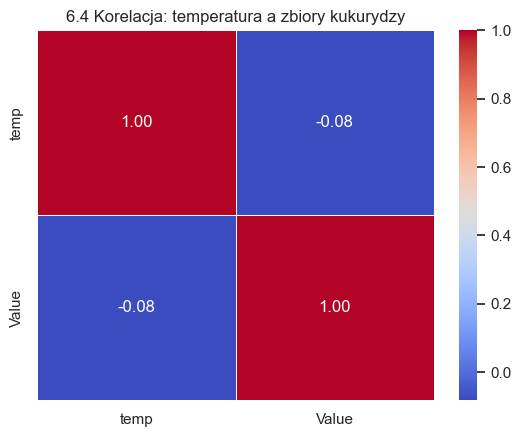

<Figure size 800x600 with 0 Axes>

           temp     Value
temp   1.000000 -0.081667
Value -0.081667  1.000000


In [45]:
#6.4
df_2_c=df_2.copy()
df_2_c["Value"] = df_2_c["Value"].replace("<null>", 0)

cols_64 = ["temp", "Value"]

df_2_c = df_2_c[(df_2['Item']=='Maize (corn)')].reset_index(drop=True)

corr_64 = correlation_heatmap(
    df_2_c,
    cols_64,
    "6.4 Korelacja: temperatura a zbiory kukurydzy"
)

print(corr_64)

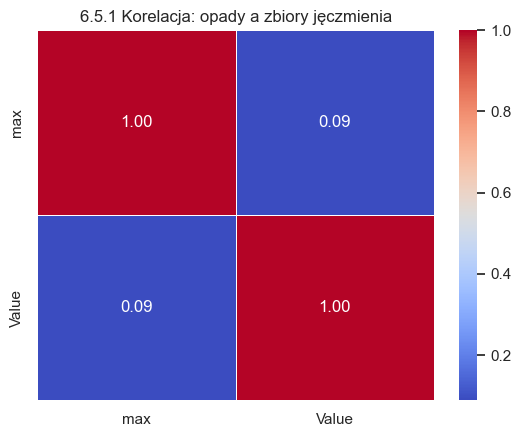

<Figure size 800x600 with 0 Axes>

            max     Value
max    1.000000  0.089806
Value  0.089806  1.000000


In [58]:
#6.5.1
df_2_d=df_2.copy()
df_2_d["Value"] = df_2_d["Value"].replace("<null>", 0)

cols_651 = ["max", "Value"]
df_2 = df_2_d[(df_2_d['Item']=='Barley')].reset_index(drop=True)

corr_651 = correlation_heatmap(
    df_2_d,
    cols_651,
    "6.5.1 Korelacja: opady a zbiory jęczmienia"
)

print(corr_651)

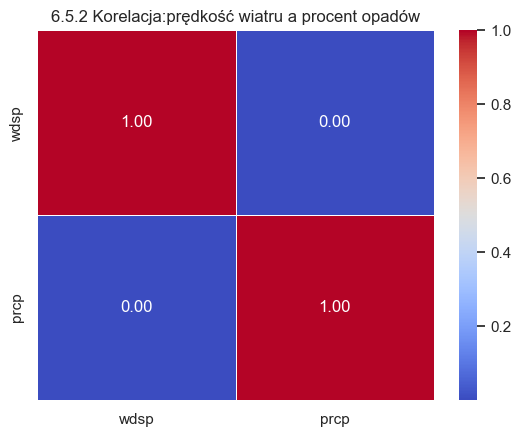

<Figure size 800x600 with 0 Axes>

          wdsp      prcp
wdsp  1.000000  0.000826
prcp  0.000826  1.000000


In [32]:
#6.5.2
cols_652 = ["wdsp","prcp"]

corr_652 = correlation_heatmap(
    df,
    cols_652,
    "6.5.2 Korelacja:prędkość wiatru a procent opadów"
)

print(corr_652)

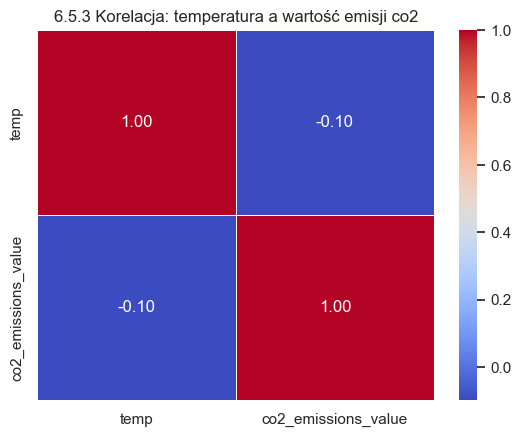

<Figure size 800x600 with 0 Axes>

                         temp  co2_emissions_value
temp                 1.000000            -0.096957
co2_emissions_value -0.096957             1.000000


In [33]:
#6.5.3
cols_653 = ["temp", "co2_emissions_value"]
corr_653 = correlation_heatmap(
    df_3,
    cols_653,
    "6.5.3 Korelacja: temperatura a wartość emisji co2"
)
print(corr_653)

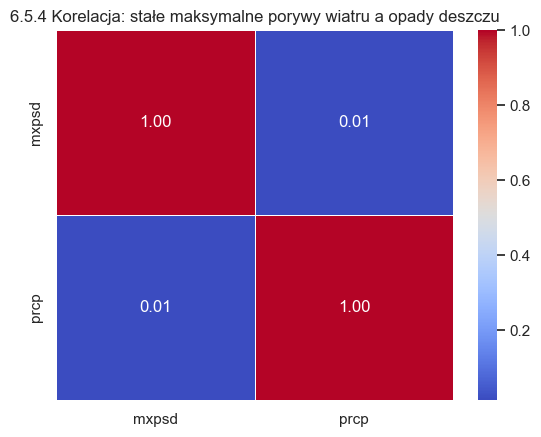

<Figure size 800x600 with 0 Axes>

          mxpsd      prcp
mxpsd  1.000000  0.013458
prcp   0.013458  1.000000


In [34]:
#6.5.4
cols_654 = ["mxpsd", "prcp"]
corr_654 = correlation_heatmap(
    df,
    cols_654,
    "6.5.4 Korelacja: stałe maksymalne porywy wiatru a opady deszczu"
)
print(corr_654)